# Assignment 1

In [118]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense, Flatten
from tensorflow.keras.utils import to_categorical
import matplotlib.pyplot as plt

In [119]:
from ucimlrepo import fetch_ucirepo 
  
# fetch dataset 
iris = fetch_ucirepo(id=53) 
  
# data (as pandas dataframes) 
X = iris.data.features 
y = iris.data.targets 

### Data preparation
Fetch data and one-hot encode labels. Scale inputs for better results

In [120]:
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
y = y.values.ravel()
encoder = LabelEncoder()
y = encoder.fit_transform(y)
# one-hot encode
y = to_categorical(y, 3)

# scale
scaler = StandardScaler()
X = scaler.fit_transform(X)

In [121]:
print(X.shape)

(150, 4)


### Model
As instructed one hidden layer and 3 celled output since the data has 3 categories. Settled on 64 cells for the middle layer after testing (32 gave worse results and 128 was very similar to 64)

In [113]:
model = Sequential([
    Input(shape=(4,)),
    Dense(64 , activation='relu'),
    Dense(3, activation='softmax')
])

In [114]:
model.compile(optimizer='rmsprop',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

In [122]:
model.summary()

Model: "sequential_26"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_52 (Dense)                │ (None, 64)             │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_53 (Dense)                │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,032 (4.04 KB)

 Trainable params: 515 (2.01 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 517 (2.02 KB)

### Training Parameters
Since the dataset is so small and we're only using one hidden layer we can run more epochs. Started seeing diminishing returns between 30-50 epochs so settled on 30. Smaller batch_size gave more consistently good models. Using a validation split larger than 0.2 immediately started overfitting the model and the validation loss started going up.

In [115]:
history = model.fit(X, y, epochs=30, batch_size=16, validation_split=0.2)

Epoch 1/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 110ms/step - accuracy: 0.5583 - loss: 0.8890 - val_accuracy: 1.0000 - val_loss: 0.6483
Epoch 2/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.7583 - loss: 0.7506 - val_accuracy: 1.0000 - val_loss: 0.6415
Epoch 3/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.8083 - loss: 0.6671 - val_accuracy: 0.9667 - val_loss: 0.6354
Epoch 4/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.8500 - loss: 0.6002 - val_accuracy: 0.9333 - val_loss: 0.6408
Epoch 5/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.8917 - loss: 0.5459 - val_accuracy: 0.8000 - val_loss: 0.6441
Epoch 6/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9083 - loss: 0.4998 - val_accuracy: 0.7667 - val_loss: 0.6423
Epoch 7/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9167 - loss: 0.4617 - val_accuracy: 0.7667 - val_loss: 0.6203
Epoch 8/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9083 - loss: 0.4291 - val_accuracy: 0.7667 - val_loss: 0.5779

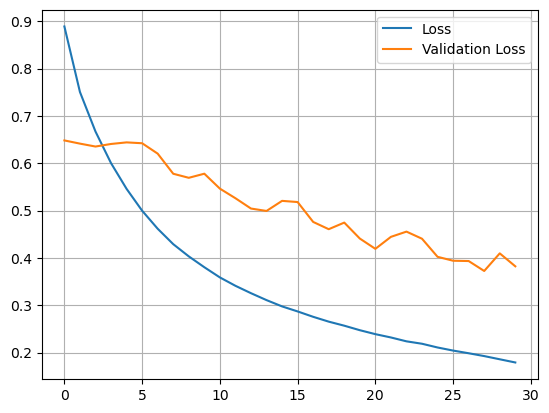

Final training accuracy: 0.9750000238418579
Final validation accuracy: 0.9333333373069763
Final training loss: 0.17912675440311432
Final validation loss: 0.38230493664741516


In [125]:
plt.plot(history.history["loss"], label="Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.legend()
plt.grid()
plt.show()

loss, acc = model.evaluate(X, y, verbose=0)


print("Final training accuracy:", history.history["accuracy"][-1])
print("Final validation accuracy:", history.history["val_accuracy"][-1])
print("Final training loss:", history.history["loss"][-1])
print("Final validation loss:", history.history["val_loss"][-1])

#### Result
97.5% Accuracy is good. Loss and validation loss both reduce reasonably. Since the dataset was so small there was a lot of variation from run to run.